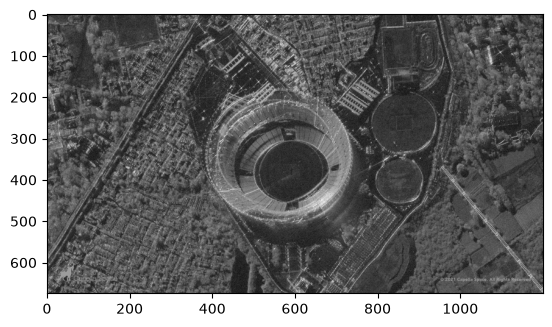

In [33]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy

image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")

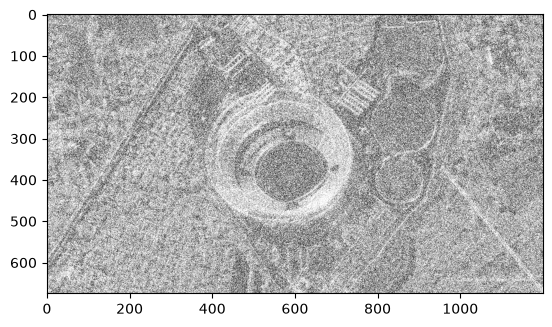

In [34]:
mean = 100
stddev = 96
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

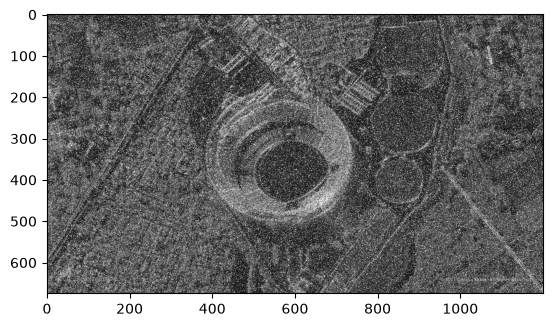

In [35]:
noise = np.random.randint(0, 11, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel  = np.where(noise == 10)

image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel]  = 255

plt.imshow(image_sp, cmap="gray")

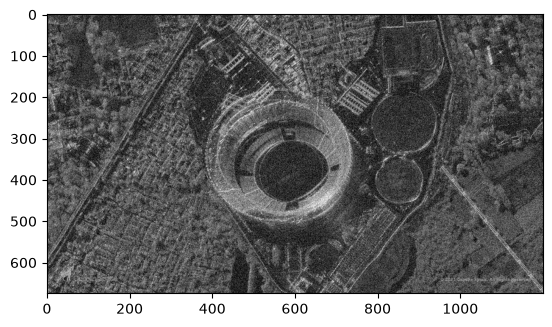

In [36]:
noise_uniform = np.random.uniform(-50, 50, image_gray.shape)
img_uniform = np.clip(image_gray.astype(np.float32) + noise_uniform, 0, 255).astype(np.uint8)
plt.imshow(img_uniform, cmap="gray")

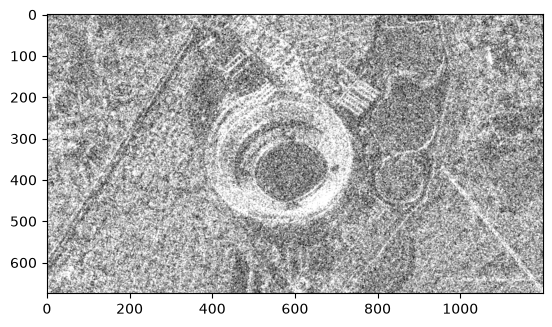

In [37]:
img_gauss_med3 = cv2.medianBlur(image_noise_gauss, 3)
img_uniform_med = cv2.medianBlur(img_uniform, 3)
plt.imshow(img_gauss_med3, cmap="gray")

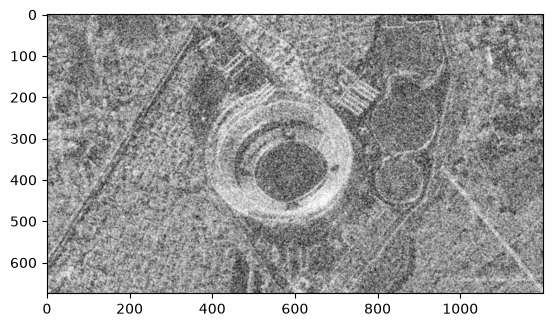

In [38]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(7,7), 1)
img_uniform_gauss = cv2.GaussianBlur(img_uniform,(7,7), 1)
plt.imshow(image_gauss_gauss, cmap="gray")

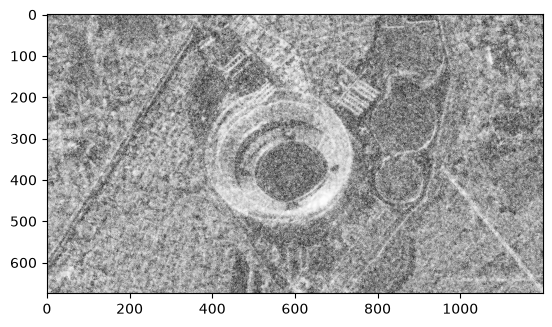

In [39]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)
img_uniform_bilat = cv2.bilateralFilter(img_uniform,9,75,75)
plt.imshow(image_gauss_bilat, cmap="gray")

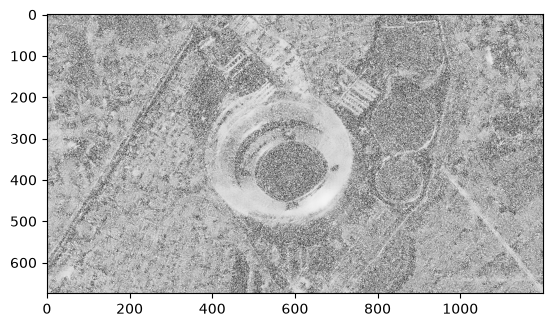

In [45]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 35)
image_uniform_nlm = cv2.fastNlMeansDenoising(img_uniform, h = 35)
plt.imshow(image_gauss_nlm, cmap="gray")

In [47]:
from skimage.metrics import structural_similarity, mean_squared_error

def score(name, filt):
    mse = mean_squared_error(image_gray, filt)
    ssim = structural_similarity(image_gray, filt)
    print(f"{name:10s}  MSE = {mse:8.2f}   SSIM = {ssim:.4f}")

print("Шумное (гаусс)       ", end="")
mse = mean_squared_error(image_gray, image_noise_gauss)
ssim = structural_similarity(image_gray, image_noise_gauss)
print(f"  MSE = {mse:8.2f}   SSIM = {ssim:.4f}")

print("Шумное (соль-перец)       ", end="")
mse = mean_squared_error(image_gray, image_sp)
ssim = structural_similarity(image_gray, image_sp)
print(f"  MSE = {mse:8.2f}   SSIM = {ssim:.4f}")

print("Шумное (постоянный)       ", end="")
mse = mean_squared_error(image_gray, img_uniform)
ssim = structural_similarity(image_gray, img_uniform)
print(f"  MSE = {mse:8.2f}   SSIM = {ssim:.4f}")

print("Гауссов", end="")
score("median3", img_gauss_med3)
score("gauss5",  image_gauss_gauss)
score("bilat",   image_gauss_bilat)
score("nlm20",   image_gauss_nlm)

print("Постоянный", end="")
score("median3", img_uniform_med)
score("gauss5",  img_uniform_gauss)
score("bilat",   img_uniform_bilat)
score("nlm20",   image_uniform_nlm)
print("Лучший для постоянного: гауссов, для постоянного: bilat/nlm")

Шумное (гаусс)         MSE = 13171.32   SSIM = 0.0965
Шумное (соль-перец)         MSE =  3590.23   SSIM = 0.1658
Шумное (постоянный)         MSE =   823.48   SSIM = 0.4149
Гауссовmedian3     MSE = 11259.83   SSIM = 0.1747
gauss5      MSE =  9425.35   SSIM = 0.3056
bilat       MSE = 10641.10   SSIM = 0.1655
nlm20       MSE = 11776.34   SSIM = 0.1300
Постоянныйmedian3     MSE =   311.50   SSIM = 0.5428
gauss5      MSE =   169.98   SSIM = 0.6883
bilat       MSE =   209.43   SSIM = 0.6091
nlm20       MSE =   294.84   SSIM = 0.4668
Лучший для постоянного: гауссов, для постоянного: bilat/nlm
